In [1]:
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("Environnement prêt et bibliothèques chargées !")

Environnement prêt et bibliothèques chargées !


In [2]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1. CHARGEMENT AUTOMATIQUE DES DONNÉES
# ==========================================
# On charge un dataset de test intégré (pas besoin de fichier CSV !)
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# La cible (ce qu'on veut prédire) est la valeur des maisons : 'MedHouseVal'
y = df['MedHouseVal']
X = df.drop('MedHouseVal', axis=1)

# Découpage du dataset : 80% pour l'entraînement, 20% pour la validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Récupération automatique du nombre de colonnes d'entrées
input_dim = X_train.shape[1]
print(f"Nombre de variables d'entrée détectées : {input_dim}")


# ==========================================
# 2. CONSTRUCTION DU RÉSEAU DE NEURONES
# ==========================================
model_reg = keras.Sequential([
    # Normalise les données d'entrée dès le départ
    layers.BatchNormalization(input_shape=[input_dim]),
    # 1ère couche cachée
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    # 2ème couche cachée
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    # Couche de sortie : 1 seul neurone SANS fonction d'activation (pour la régression)
    layers.Dense(1),
])


# ==========================================
# 3. COMPILATION DU MODÈLE
# ==========================================
model_reg.compile(
    optimizer='adam',
    loss='mae',  # Mean Absolute Error
)


# ==========================================
# 4. CONFIGURATION DE L'EARLY STOPPING
# ==========================================
early_stopping = EarlyStopping(
    min_delta=0.001,
    patience=20,
    restore_best_weights=True,
)


# ==========================================
# 5. ENTRAÎNEMENT DU MODÈLE
# ==========================================
history = model_reg.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=500,
    callbacks=[early_stopping],
    verbose=1,
)

Nombre de variables d'entrée détectées : 8


/usr/local/lib/python3.13/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.4236 - val_loss: 3.0035
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7707 - val_loss: 3.4570
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6479 - val_loss: 1.6554
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5839 - val_loss: 1.1866
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5441 - val_loss: 0.8274
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5216 - val_loss: 0.6783
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4962 - val_loss: 0.5714
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4871 - val_loss: 0.5016
Epoch 9/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4798 - val_loss: 0.4814
Epoch 10/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4651 - val_loss: 0.4916
Epoch 11/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4580 - val_loss: 0.4671
Epoch 12/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

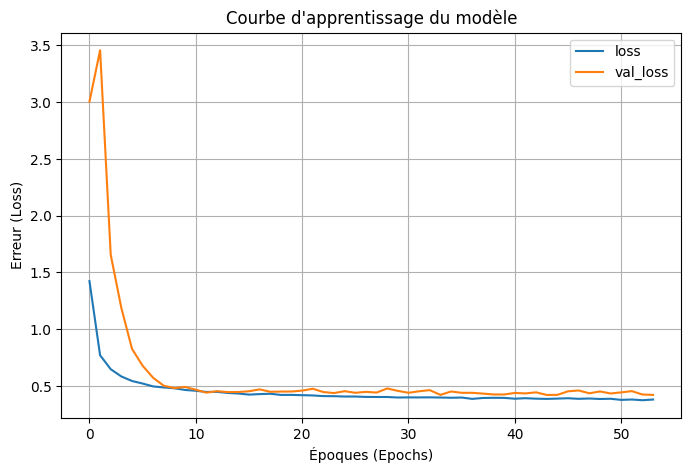

In [3]:
import matplotlib.pyplot as plt

# Convertir l'historique d'entraînement en tableau (DataFrame)
history_df = pd.DataFrame(history.history)

# Tracer la courbe de perte (loss) pour l'entraînement et la validation
history_df.loc[:, ['loss', 'val_loss']].plot(figsize=(8, 5))
plt.title("Courbe d'apprentissage du modèle")
plt.xlabel("Époques (Epochs)")
plt.ylabel("Erreur (Loss)")
plt.grid(True)
plt.show()